# Traffic-signal-control experiment

This notebook compares simple baselines, MAPPO, and reward-sharing MAPPO on a network.

In [2]:
import os
import subprocess
import sys
import sysconfig
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path("/content/marl-tsc")

    if not ROOT.exists():
        subprocess.run([
            "git", "clone", "--branch", "zak-pre-experiment",
            "--single-branch", "https://github.com/abergh18/marl-tsc.git",
            str(ROOT)
        ], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "eclipse-sumo"
    ], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "-r", str(ROOT / "requirements.txt"),
    ], check=True)

    import sumo
    os.environ["SUMO_HOME"] = sumo.SUMO_HOME
    sys.path.insert(0, os.path.join(sumo.SUMO_HOME, "tools"))

    from google.colab import userdata

    #Get access token
    token = userdata.get('GH_TOKEN')

else:
    # Run VS Code from somewhere inside the marl-tsc repository.
    ROOT = next(
        folder
        for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / "src" / "marl_tsc").exists()
    )

# Make /src/marl_tsc importable.
sys.path.insert(0, str(ROOT / "src"))

# Relative project paths now work consistently.
os.chdir(ROOT)

print(f"Running in {'Colab' if IN_COLAB else 'VS Code'} from {ROOT}")

Running in Colab from /content/marl-tsc


In [3]:
if not IN_COLAB:
  %reload_ext autoreload
  %autoreload 2

import matplotlib.pyplot as plt

from marl_tsc.baselines import fixed_time_actions, random_actions
from marl_tsc.mappo import train_mappo
from marl_tsc.network_types import CityNetwork, GridNetwork
from marl_tsc.simulation_generator import SimulationGenerator
from marl_tsc.training import (
    evaluate_policies,
    export_policy_replay,
    evaluation_results_table,
    plot_training_histories,
)

## 1. Configure and generate the simulation

In [4]:
import urllib.request

if IN_COLAB:
    # Create a custom opener to disguise script as a web browser
    opener = urllib.request.build_opener()
    opener.addheaders = [
        ("User-Agent", "Mozilla/5.0 (Windows NT 10.0; Win64; x64)")
    ]

    # Apply this rule globally for this notebook
    urllib.request.install_opener(opener)

In [5]:
SEED = 40
EPISODE_STEPS = 600
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)
TOTAL_TIMESTEPS = 250_000
EVALUATION_EPISODES = 3

# The same environment settings are used for training, evaluation, and replay.
ENV_KWARGS = {
    "green_phase_count": None,
    "min_green_seconds": 10,
    "seconds_per_action": SECONDS_PER_ACTION,
    "switch_penalty": 0.1,
    "collect_global_metrics": True,
    "global_metric_interval": 10,
}

OUTPUT_DIR = ROOT / "outputs"
SIMULATION_DIR = OUTPUT_DIR / "simulation"
network = GridNetwork(4)
#network = GridNetwork(5)
#network = CityNetwork(city_name="The Bearpit, Bristol, UK", radius=280)
#network = CityNetwork(city_name="Camberwell Green, London, UK", radius=500)
#network = CityNetwork(city_name="Park Square, Sheffield, UK", radius=425)
generator = SimulationGenerator(
    output_dir=SIMULATION_DIR,
    network=network,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,
    trip_period=2,
    seed=SEED,
)

paths = generator.generate_all()
traffic_light_ids = list(paths.traffic_light_ids)
print(f"Generated SUMO config: {paths.config_file}")
print(f"Traffic-light agent count: {len(traffic_light_ids)}")

Generated SUMO config: /content/marl-tsc/outputs/simulation/config.sumocfg
Traffic-light agent count: 4


## 2. Train MAPPO policies

The reward-sharing policy has an extra sharing action during training. Both policies are evaluated using the same traffic metrics.

In [ ]:
# Use the same arguements for all MAPPO training; use_peer_reward will be set individually
MAPPO_KWARGS = {
    "config_file": paths.config_file,
    "traffic_light_ids": traffic_light_ids,
    "output_dir": OUTPUT_DIR,
    "total_timesteps": TOTAL_TIMESTEPS,
    "rollout_steps": 500,
    "max_steps": EPISODE_STEPS,
    "seed": SEED,
    "learning_rate": 5e-4,
    "env_kwargs": ENV_KWARGS,
}

mappo_model, mappo_history, mappo_model_path = train_mappo(
    **MAPPO_KWARGS,
    use_peer_reward=False,
)

 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -300.09 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -321.67 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -314.31 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -295.71 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -315.39 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -290.62 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -297.27 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -295.09 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -312.59 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -303.32 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -286.50 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -276.18 | Total Steps: 7200
 Retrying in 1 seconds
[MAP

In [ ]:
reward_sharing_model, reward_sharing_history, reward_sharing_model_path = train_mappo(
    **MAPPO_KWARGS,
    use_peer_reward=True,
)

 Retrying in 1 seconds
 Retrying in 1 seconds

Discovered Network Neighbours (Live TraCI):
  B1 -> ['C2', 'B2', 'C1']
  B2 -> ['C2', 'B1', 'C1']
  C1 -> ['C2', 'B1', 'B2']
  C2 -> ['B1', 'B2', 'C1']

[MAPPO] Episode 1 | Return: -283.51 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -331.38 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -283.32 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -305.60 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -316.02 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -296.24 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -299.91 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -283.72 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -306.08 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -267.54 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Ep

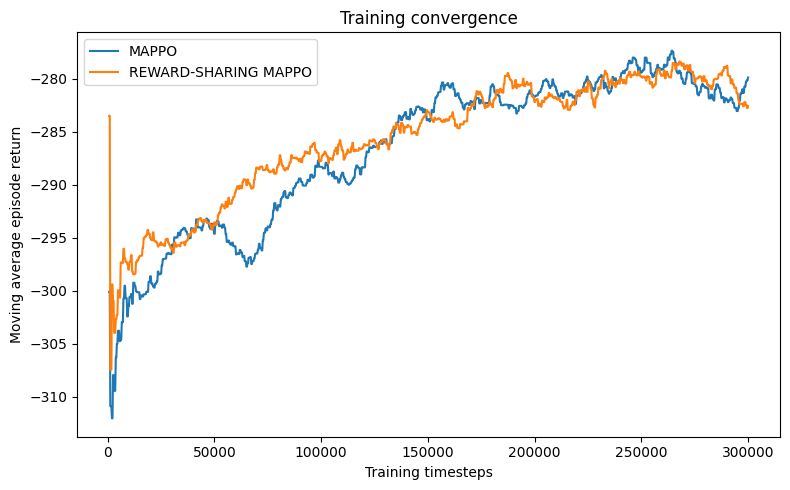

In [ ]:
fig, ax = plot_training_histories({
    "MAPPO": mappo_history,
    "Reward-sharing MAPPO": reward_sharing_history,
})
plt.show()

## 3. Export a SUMO replay

In [ ]:
replay_config = export_policy_replay(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policy=reward_sharing_model,
    output_dir=OUTPUT_DIR / "replays" / "reward_sharing_mappo",
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)
print(f"Open this file in the SUMO GUI: {replay_config}")

 Retrying in 1 seconds
 Retrying in 1 seconds
Open this file in the SUMO GUI: /content/marl-tsc/outputs/replays/reward_sharing_mappo/replay.sumocfg


## 4. Compare all policies

Every policy uses the same evaluation episodes, seeds, and environment settings.

In [ ]:
policies = {
    "Random": random_actions,
    "Fixed-Time": fixed_time_actions,
    "MAPPO": mappo_model,
    "Reward-sharing MAPPO": reward_sharing_model,
}

policy_results = evaluate_policies(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    policies=policies,
    episodes=EVALUATION_EPISODES,
    max_steps=EPISODE_STEPS,
    seed=SEED,
    env_kwargs=ENV_KWARGS,
)

display(evaluation_results_table(policy_results))

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1131.81
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1239.28
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1264.03
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -988.47
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -987.34
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -982.47
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -456.25
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -431.47
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -431.22
Evaluating Reward-shar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait
0,Random,-1211.7083,0.5046,8.3333,20.8957,244.6667
1,Fixed-Time,-986.0938,0.4106,5.0000,15.3450,89.0000
2,MAPPO,-439.6458,0.1831,4.6667,6.6819,249.6667
3,Reward-sharing MAPPO,-379.9792,0.1582,3.6667,3.5351,128.0000


## 5. Seeded Experiments 4x4

In [6]:
SAVE_TO_DRIVE = True

if IN_COLAB and SAVE_TO_DRIVE:
  from google.colab import drive
  drive.mount('/content/drive')
  OUTPUT_DIR = '/content/drive/MyDrive/Uni-Masters/Group Project/outputs/exp_histories/final'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
OUTPUT_DIR

'/content/drive/MyDrive/Uni-Masters/Group Project/outputs/exp_histories/final'

|Seed: 46 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -274.28 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -291.26 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -306.55 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -295.73 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -307.69 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -332.89 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -309.83 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -332.04 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -324.31 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -295.17 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -318.75 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -309.03 | Total Steps: 7200
 

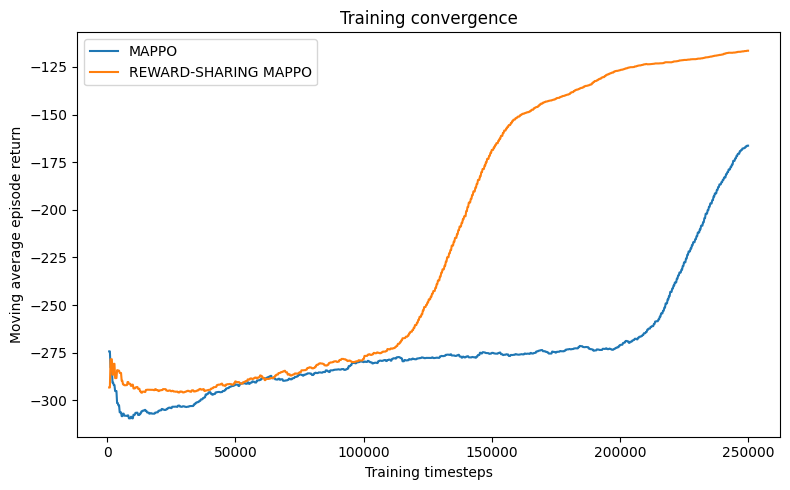

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1274.66
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1077.56
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1197.72
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -973.47
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -975.69
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -973.31
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -472.41
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -481.53
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -501.75
Evaluating Reward-shar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait
0,Random,-1183.3125,0.4928,9.0000,20.7035,235.6667
1,Fixed-Time,-974.1562,0.4056,6.0000,14.4840,88.3333
2,MAPPO,-485.2292,0.2020,4.0000,5.1404,125.0000
3,Reward-sharing MAPPO,-377.2396,0.1571,3.3333,3.2762,92.6667


|Seed: 47 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -317.51 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -299.49 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -289.07 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -349.61 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -331.52 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -292.29 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -316.34 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -321.03 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -315.58 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -295.21 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -351.35 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -294.95 | Total Steps: 7200
 

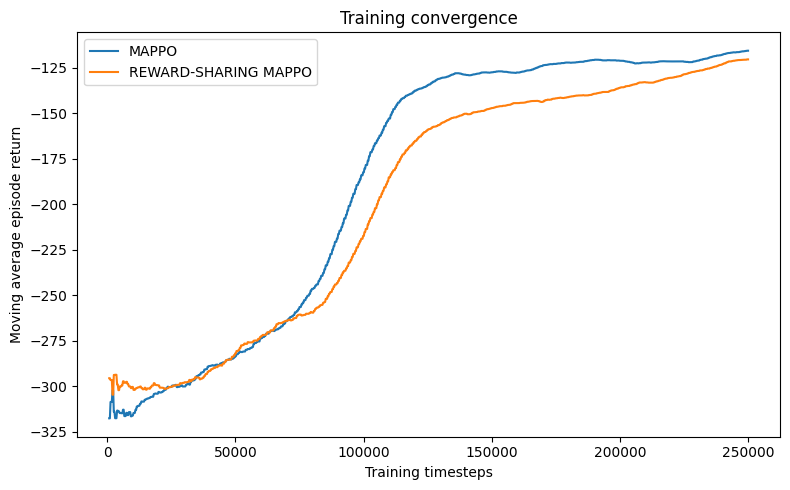

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1077.56
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1197.72
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1185.56
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -975.69
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -973.31
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -966.06
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -388.09
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -386.38
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -382.25
Evaluating Reward-shar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait
0,Random,-1153.6146,0.4805,8.0000,19.9224,242.6667
1,Fixed-Time,-971.6875,0.4046,6.0000,14.4422,88.0000
2,MAPPO,-385.5729,0.1605,3.6667,4.1564,171.0000
3,Reward-sharing MAPPO,-384.2292,0.1600,3.3333,3.3956,127.3333


|Seed: 48 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -291.14 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -327.19 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -324.60 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -304.35 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -302.65 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -298.36 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -302.68 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -279.98 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -287.88 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -305.24 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -314.26 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -297.54 | Total Steps: 7200
 

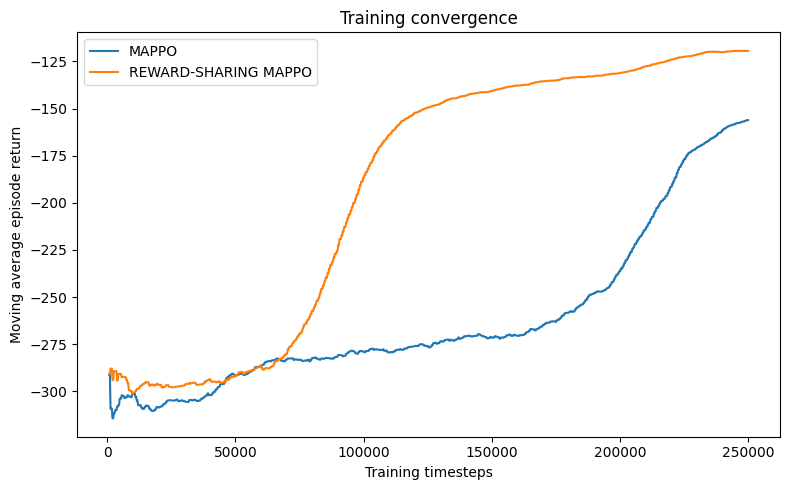

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1197.72
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1185.56
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1113.69
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -973.31
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -966.06
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -973.44
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -489.31
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -477.34
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -496.00
Evaluating Reward-shar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait
0,Random,-1165.6562,0.4854,7.6667,19.8055,245.6667
1,Fixed-Time,-970.9375,0.4043,6.0000,14.4392,88.0000
2,MAPPO,-487.5521,0.2031,5.0000,4.7580,135.0000
3,Reward-sharing MAPPO,-390.1354,0.1625,4.3333,3.5643,127.0000


|Seed: 49 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -293.74 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -268.98 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -302.64 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -309.05 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -305.90 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -334.15 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -342.92 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -287.85 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -346.33 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -324.87 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -309.61 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -292.22 | Total Steps: 7200
 

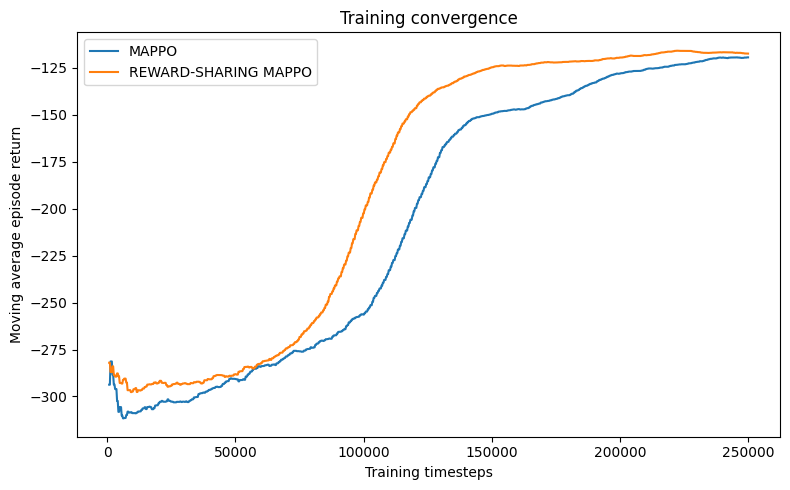

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1185.56
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1113.69
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1140.81
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -966.06
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -973.44
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -971.31
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -395.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -377.78
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -392.53
Evaluating Reward-shar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait
0,Random,-1146.6875,0.4775,7.3333,18.8232,254.6667
1,Fixed-Time,-970.2708,0.4040,6.0000,14.3975,87.6667
2,MAPPO,-388.7292,0.1619,3.3333,3.2085,99.3333
3,Reward-sharing MAPPO,-377.0625,0.1570,4.6667,3.2059,91.0000


|Seed: 50 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -314.28 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -311.65 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -287.58 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -309.21 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -279.81 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -307.14 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -286.28 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -281.21 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -285.61 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -305.02 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -338.78 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -315.41 | Total Steps: 7200
 

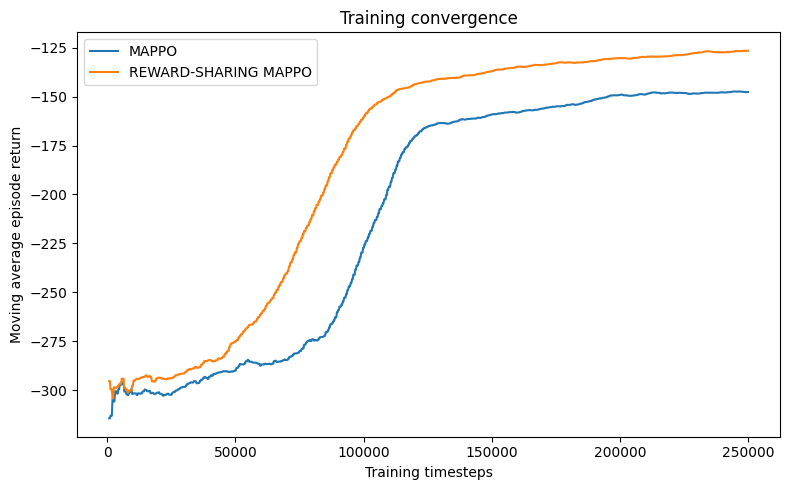

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1113.69
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1140.81
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1191.34
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -973.44
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -971.31
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -970.78
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -500.53
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -479.62
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -470.66
Evaluating Reward-shar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait
0,Random,-1148.6146,0.4783,8.0000,18.6012,255.6667
1,Fixed-Time,-971.8438,0.4047,6.0000,14.4198,88.0000
2,MAPPO,-483.6042,0.2014,5.0000,4.5231,84.6667
3,Reward-sharing MAPPO,-411.4479,0.1714,3.6667,4.0068,111.0000


|Seed: 51 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -308.22 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -325.38 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -324.52 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -302.37 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -294.70 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -294.54 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -322.12 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -309.31 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -277.75 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -305.99 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -305.43 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -325.96 | Total Steps: 7200
 

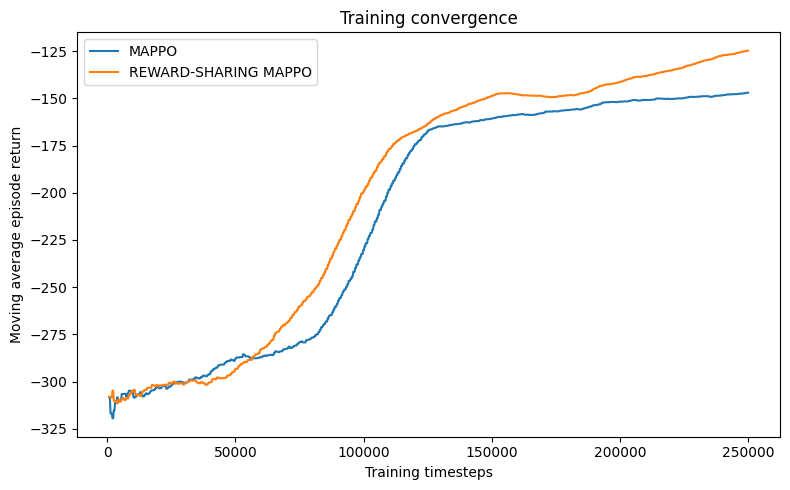

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1140.81
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1191.34
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1246.84
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -971.31
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -970.78
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -960.06
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -473.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -517.50
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -484.91
Evaluating Reward-shar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait
0,Random,-1193.0000,0.4968,8.3333,19.9220,277.6667
1,Fixed-Time,-967.3854,0.4028,6.0000,14.4136,88.3333
2,MAPPO,-492.1146,0.2049,4.3333,4.9539,119.3333
3,Reward-sharing MAPPO,-403.1146,0.1678,3.0000,3.5110,91.6667


|Seed: 52 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -299.40 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -287.64 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -296.22 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -318.40 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -316.18 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -306.57 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -306.83 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -285.80 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -287.31 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -286.01 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -289.25 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -295.86 | Total Steps: 7200
 

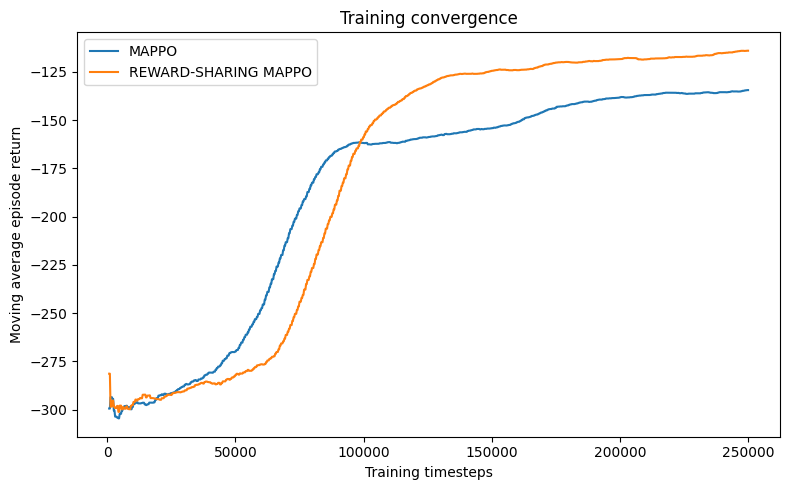

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1191.34
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1246.84
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1096.47
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -970.78
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -960.06
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -976.72
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -432.41
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -440.88
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -457.84
Evaluating Reward-shar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait
0,Random,-1178.2188,0.4907,7.6667,19.7946,282.3333
1,Fixed-Time,-969.1875,0.4035,6.0000,14.4823,89.3333
2,MAPPO,-443.7083,0.1848,5.3333,4.7082,160.0000
3,Reward-sharing MAPPO,-371.4896,0.1547,3.6667,3.3383,110.3333


|Seed: 53 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -295.21 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -294.05 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -322.18 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -292.41 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -345.20 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -324.55 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -322.82 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -307.27 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -336.92 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -285.01 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -365.46 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -299.72 | Total Steps: 7200
 

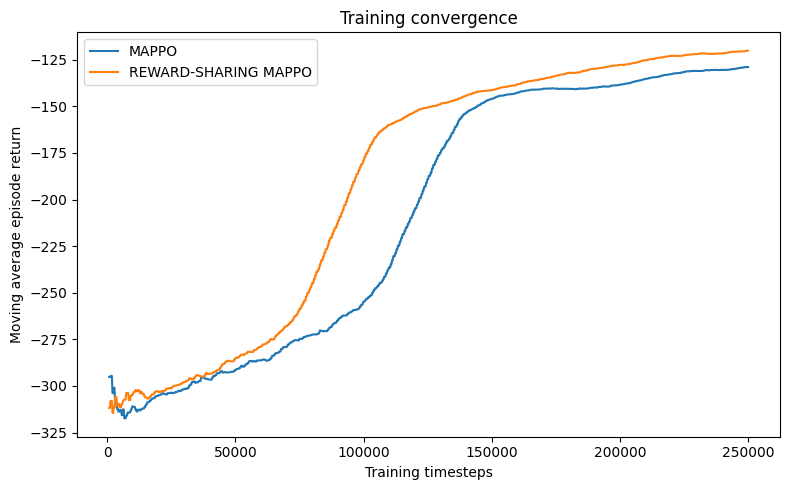

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1246.84
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1096.47
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1158.84
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -960.06
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -976.72
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -975.94
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -390.09
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -406.00
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -422.75
Evaluating Reward-shar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait
0,Random,-1167.3854,0.4861,7.6667,19.8504,282.3333
1,Fixed-Time,-970.9062,0.4043,6.0000,14.5470,89.0000
2,MAPPO,-406.2812,0.1692,4.0000,3.8662,123.3333
3,Reward-sharing MAPPO,-394.9062,0.1644,3.6667,3.5856,117.0000


|Seed: 54 used for sweep|
 Retrying in 1 seconds
 Retrying in 1 seconds
[MAPPO] Episode 1 | Return: -307.43 | Total Steps: 600
 Retrying in 1 seconds
[MAPPO] Episode 2 | Return: -302.65 | Total Steps: 1200
 Retrying in 1 seconds
[MAPPO] Episode 3 | Return: -294.05 | Total Steps: 1800
 Retrying in 1 seconds
[MAPPO] Episode 4 | Return: -336.33 | Total Steps: 2400
 Retrying in 1 seconds
[MAPPO] Episode 5 | Return: -315.33 | Total Steps: 3000
 Retrying in 1 seconds
[MAPPO] Episode 6 | Return: -302.33 | Total Steps: 3600
 Retrying in 1 seconds
[MAPPO] Episode 7 | Return: -284.60 | Total Steps: 4200
 Retrying in 1 seconds
[MAPPO] Episode 8 | Return: -319.86 | Total Steps: 4800
 Retrying in 1 seconds
[MAPPO] Episode 9 | Return: -302.33 | Total Steps: 5400
 Retrying in 1 seconds
[MAPPO] Episode 10 | Return: -331.69 | Total Steps: 6000
 Retrying in 1 seconds
[MAPPO] Episode 11 | Return: -329.78 | Total Steps: 6600
 Retrying in 1 seconds
[MAPPO] Episode 12 | Return: -282.15 | Total Steps: 7200
 

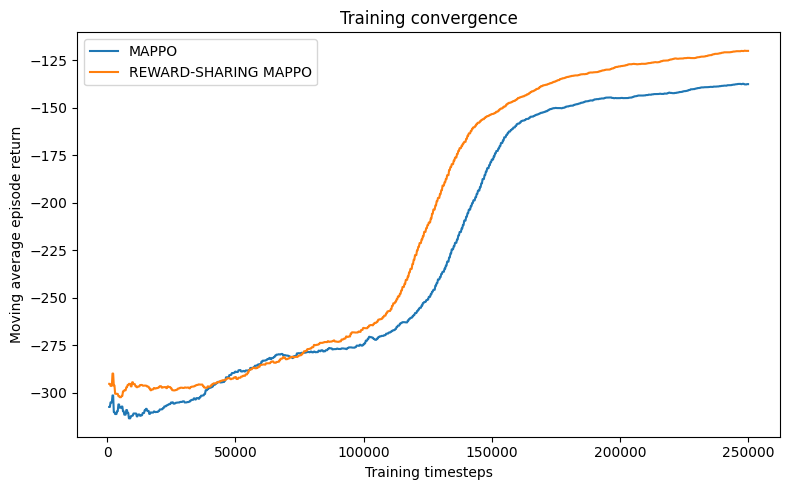

Evaluating Random
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -1096.47
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -1158.84
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -1245.78
Evaluating Fixed-Time
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -976.72
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -975.94
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -965.22
Evaluating MAPPO
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 1/3 - Total Reward: -444.22
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 2/3 - Total Reward: -444.19
 Retrying in 1 seconds
 Retrying in 1 seconds
Finished Evaluation Episode 3/3 - Total Reward: -445.19
Evaluating Reward-shar

,Policy,Mean reward,Mean queue,Mean max queue,Mean wait,Mean max wait
0,Random,-1167.0312,0.4860,7.3333,19.6307,271.6667
1,Fixed-Time,-972.6250,0.4050,6.0000,14.5162,89.3333
2,MAPPO,-444.5312,0.1852,4.0000,4.1978,99.3333
3,Reward-sharing MAPPO,-390.0938,0.1624,3.6667,3.2209,109.0000


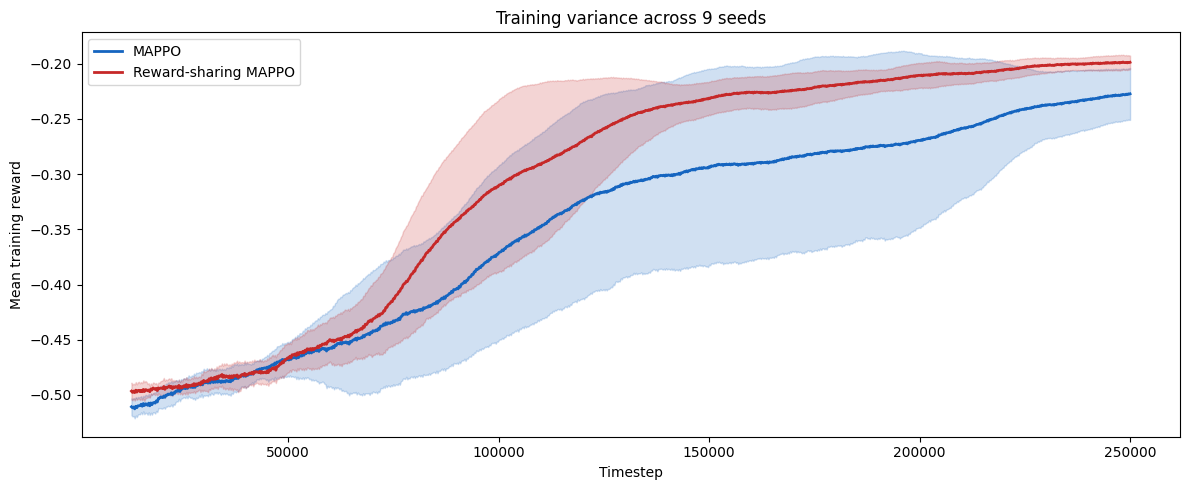

In [9]:
EXP_SWEEP = True

SEED = 46
SEED_RANGE = 9
LEARNING_RATE = 3e-3

if EXP_SWEEP:
    from marl_tsc.exp_functions import save_history, plot_variance
    import torch
    import datetime
    time_stamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    grid= "4x4"

    #select network for seeded evaluation
    network = GridNetwork(4)
    generator = SimulationGenerator(
      output_dir=SIMULATION_DIR,
      network=network,
      trip_begin=0,
      trip_end=TRAFFIC_SPAWN_DURATION,
      trip_period=3,
      seed=SEED,
    )

    paths = generator.generate_all()
    traffic_light_ids = list(paths.traffic_light_ids)

    histories_mappo = []
    histories_rs   = []
    evaluation_histories = []

    ran_single_above = False
    if ran_single_above:
      histories_mappo.append(mappo_history)
      histories_rs.append(reward_sharing_history)
      evaluation_histories.append(policy_results)

    #Run seeded experiment sweeps
    for seed in range(SEED, SEED + SEED_RANGE):
          torch.manual_seed(seed)
          print(f"|Seed: {seed} used for sweep|")
          MAPPO_KWARGS = {
              "config_file": paths.config_file,
              "traffic_light_ids": traffic_light_ids,
              "output_dir": OUTPUT_DIR,
              "total_timesteps": TOTAL_TIMESTEPS,
              "rollout_steps": 256,
              "max_steps": EPISODE_STEPS,
              "seed": seed,
              "learning_rate": LEARNING_RATE,
              "env_kwargs": ENV_KWARGS,
          }

          mappo_model, mappo_history, mappo_model_path = train_mappo(
              **MAPPO_KWARGS,
              use_peer_reward=False,
          )
          reward_sharing_model, reward_sharing_history, reward_sharing_model_path = train_mappo(
              **MAPPO_KWARGS,
              use_peer_reward=True,
          )
          #Append and save
          histories_mappo.append(mappo_history)#accumulate in memory
          histories_rs.append(reward_sharing_history)
          save_history(mappo_history, seed, f"mappo_{grid}_@{TOTAL_TIMESTEPS}steps_lr={LEARNING_RATE}_{time_stamp}", OUTPUT_DIR)#save to as backup
          save_history(reward_sharing_history, seed, f"rs__{grid}_@{TOTAL_TIMESTEPS}steps_lr={LEARNING_RATE}_{time_stamp}", OUTPUT_DIR)

          #Display
          fig, ax = plot_training_histories({
          "MAPPO": mappo_history,
          "Reward-sharing MAPPO": reward_sharing_history,
          })
          plt.show()

          #Evaluate
          policies = {
          "Random": random_actions,
          "Fixed-Time": fixed_time_actions,
          "MAPPO": mappo_model,
          "Reward-sharing MAPPO": reward_sharing_model,
          }

          policy_results = evaluate_policies(
              config_file=paths.config_file,
              traffic_light_ids=traffic_light_ids,
              policies=policies,
              episodes=EVALUATION_EPISODES,
              max_steps=EPISODE_STEPS,
              seed=seed,
              env_kwargs=ENV_KWARGS,
          )
          evaluation_histories.append(policy_results)
          save_history(policy_results, seed, f"evaluation_{grid}_@{TOTAL_TIMESTEPS}steps_lr={LEARNING_RATE}_{time_stamp}", OUTPUT_DIR)

          display(evaluation_results_table(policy_results))

    fig, ax = plt.subplots(figsize=(12, 5))
    plot_variance(histories_mappo, "MAPPO",              "#1565C0", ax)
    plot_variance(histories_rs,   "Reward-sharing MAPPO", "#C62828", ax)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Mean training reward")
    ax.legend()
    ax.set_title(f"Training variance across {SEED_RANGE} seeds")
    plt.tight_layout()
    plt.show()

### Results (Loaded from Drive)

In [ ]:
LOAD_FROM_DRIVE = False
if LOAD_FROM_DRIVE:
  from google.colab import drive
  drive.mount('/content/drive')
  OUTPUT_DIR = '/content/drive/MyDrive/Uni-Masters/Group Project/outputs/exp_histories'

  import json
  from pathlib import Path

  # Your OUTPUT_DIR should already point to Drive
  output_dir = Path(OUTPUT_DIR)

  # Load all histories by type
  def load_histories(pattern):
      paths = sorted(output_dir.glob(pattern))
      histories = []
      for p in paths:
          with open(p) as f:
              histories.append(json.load(f))
      print(f"Loaded {len(histories)} histories matching '{pattern}'")
      return histories

  # Training histories
  histories_mappo = load_histories("history_mappo_4x4_@300000steps*.json")
  histories_rs    = load_histories("history_rs__4x4_@300000steps*.json")
  evaluation_histories  = load_histories("history_evaluation_4x4_@300000steps*.json")

  print(f"MAPPO seeds: {len(histories_mappo)}")
  print(f"RS seeds:    {len(histories_rs)}")
  print(f"Eval seeds:  {len(evaluation_histories)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 9 histories matching 'history_mappo_4x4_@300000steps*.json'
Loaded 9 histories matching 'history_rs__4x4_@300000steps*.json'
Loaded 9 histories matching 'history_evaluation_4x4_@300000steps*.json'
MAPPO seeds: 9
RS seeds:    9
Eval seeds:  9


#### Training Graphs (Seed by Seed)

In [ ]:
if LOAD_FROM_DRIVE:
    #4x4
    for seed_idx, (mappo_hist, rs_hist) in enumerate(zip(histories_mappo, histories_rs)):
      seed = 42 + seed_idx
      print(f"\nSeed {seed}")

      # Training plots
      fig, ax = plot_training_histories({
          "MAPPO": mappo_hist,
          "Reward-sharing MAPPO": rs_hist,
      })

      plt.show()

#### Evaluation Runs

In [ ]:
#eval load

### Cross Seed Analysis

#### Variance Graph: Training

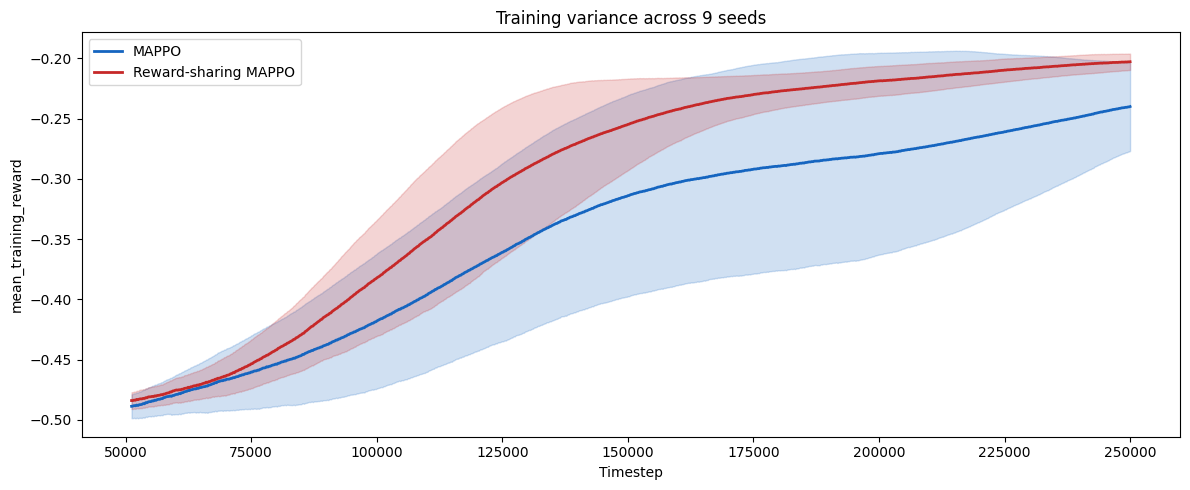

In [17]:
from marl_tsc.exp_functions import plot_variance
smooth = 200
metric = "mean_training_reward"
fig, ax = plt.subplots(figsize=(12, 5))
plot_variance(histories_mappo, "MAPPO",              "#1565C0", ax, metric=metric,smooth=smooth)
plot_variance(histories_rs,   "Reward-sharing MAPPO", "#C62828", ax, metric=metric, smooth=smooth)
ax.set_xlabel("Timestep")
ax.set_ylabel(f"{metric}")
ax.legend()
ax.set_title(f"Training variance across {len(histories_rs)} seeds")
plt.tight_layout()
plt.show()

#### Statistical Significance: Training

In [11]:
EXP_ANALYSIS = True
if EXP_ANALYSIS:
    from scipy import stats
    import numpy as np

    def training_auc(history, metric="mean_training_reward"):
        values = [h[metric] for h in history if metric in h]
        return float(np.trapezoid(values))


    def compare_training_histories(
        histories_a,
        histories_b,
        label_a="MAPPO",
        label_b="Reward-sharing MAPPO",
        metric="mean_training_reward",
        test_type="wilk",
    ):
        print(f"\nMetric: {metric}")
        print("=" * 60)

        # AUC
        aucs_a = [training_auc(h, metric) for h in histories_a]
        aucs_b = [training_auc(h, metric) for h in histories_b]
        print(f"\nAUC (total area under training curve):")
        print(f"  {label_a}: {np.mean(aucs_a):.2f} ± {np.std(aucs_a):.2f}")
        print(f"  {label_b}: {np.mean(aucs_b):.2f} ± {np.std(aucs_b):.2f}")
        if test_type == "wilk":
            stat, p = stats.wilcoxon(aucs_a, aucs_b)
        else:
            stat, p = stats.ttest_rel(aucs_a, aucs_b)

        print(f"  W={stat:.3f}, p={p:.4f}")

        if p < 0.05:
            print(f"  {label_a} and {label_b} show significantly different results")
        else:
            print(f"  {label_a} and {label_b} do not show significantly different results")

    compare_training_histories(
        histories_a=histories_mappo,
        histories_b=histories_rs,
        metric="mean_training_reward",
    )


Metric: mean_training_reward

AUC (total area under training curve):
  MAPPO: -339.17 ± 47.36
  Reward-sharing MAPPO: -300.58 ± 18.14
  W=3.000, p=0.0195
  MAPPO and Reward-sharing MAPPO show significantly different results


#### Overall Performance Metrics: Evaluation

In [12]:
if EXP_ANALYSIS:
  import numpy as np
  import pandas as pd
  metrics = ["mean_total_reward", "mean_local_queue", "mean_waiting_time",
            "mean_max_waiting_time", "mean_total_time_loss"]

  rows = []
  for policy_name in ["Random", "Fixed-Time", "MAPPO", "Reward-sharing MAPPO"]:
      row = {"Policy": policy_name}
      for metric in metrics:
          values = [e[policy_name][metric] for e in evaluation_histories]
          row[f"{metric}_mean"] = np.mean(values)
          row[f"{metric}_std"]  = np.std(values)
      rows.append(row)

  df = pd.DataFrame(rows)
  print('Overall Performance Accross 9 seeds')
  display(df)

Overall Performance Accross 9 seeds


,Policy,mean_total_reward_mean,mean_total_reward_std,mean_local_queue_mean,mean_local_queue_std,mean_waiting_time_mean,mean_waiting_time_std,mean_max_waiting_time_mean,mean_max_waiting_time_std,mean_total_time_loss_mean,mean_total_time_loss_std
0,Random,-1167.057870,14.905904,0.486015,0.006211,19.672623,0.589055,260.925926,16.942005,1612.482093,58.791209
1,Fixed-Time,-971.000000,1.846374,0.404296,0.000767,14.460191,0.047399,88.444444,0.587945,1092.674998,2.797016
2,MAPPO,-446.369213,41.259710,0.185882,0.017186,4.390279,0.567377,124.111111,26.693968,443.241396,34.504681
3,Reward-sharing MAPPO,-388.857639,12.249735,0.161919,0.005107,3.456062,0.236319,108.555556,13.413647,387.126974,12.331698


#### Statistical Significance Tests: Evaluation

In [13]:
if EXP_ANALYSIS:
  # Extract metric across seeds for each policy
  def perform_statisical_tests(metric, evaluation_histories, test_type):
    from scipy import stats
    mappo_grouping = [e["MAPPO"][metric] for e in evaluation_histories]
    rs_grouping   = [e["Reward-sharing MAPPO"][metric] for e in evaluation_histories]

    # Paired t-test — paired because same seed = same traffic conditions
    if test_type == "paired_t":
      _stat, p_value = stats.ttest_rel(mappo_grouping, rs_grouping)
      #print(f"t={_stat:.5f}, p={p_value:.4f}")
    elif test_type == 'wilk':
      _stat, p_value = stats.wilcoxon(mappo_grouping, rs_grouping)
      #print(f"W={_stat:.5f}, p={p_value:.4f}")
    else:
      raise ValueError(f"Unknown test type: {test_type}")

    return _stat, p_value

  metrics = ["mean_total_reward", "mean_local_queue", "mean_waiting_time",
            "mean_max_waiting_time", "mean_total_time_loss"]
  for metric in metrics:
    print(f"Metric) {metric}:")

    w, p = perform_statisical_tests(metric, evaluation_histories, "wilk")
    print(f"    Wilcoxon: t={w:.5f}, p={p:.4f}")
    if p < 0.05:
      print(f"    {metric} shows significantly different results between groups")
    else:
      print(f"    {metric} does not show significantly different results between groups ")
    print('')


Metric) mean_total_reward:
    Wilcoxon: t=0.00000, p=0.0039
    mean_total_reward shows significantly different results between groups

Metric) mean_local_queue:
    Wilcoxon: t=0.00000, p=0.0039
    mean_local_queue shows significantly different results between groups

Metric) mean_waiting_time:
    Wilcoxon: t=0.00000, p=0.0039
    mean_waiting_time shows significantly different results between groups

Metric) mean_max_waiting_time:
    Wilcoxon: t=9.00000, p=0.1289
    mean_max_waiting_time does not show significantly different results between groups 

Metric) mean_total_time_loss:
    Wilcoxon: t=0.00000, p=0.0039
    mean_total_time_loss shows significantly different results between groups



In [ ]:
#print( f"Keys for mappo history: {histories_mappo[0][0].keys()}")

In [ ]:
#print(f"Keys for rs-mappo history: {histories_rs[0][0].keys()}")

In [ ]:
#print(f'''Evaluation history Keys:
#{evaluation_histories[0]['MAPPO'].keys()}''')

In [ ]:
!git status
#!git add .
commit = False
if commit:
  import shlex
  commit_msg = '''
  Updated to reflect gifts recieved as well as given
  '''
  !git config --global user.email user_email
  !git config --global user.name 'IsaacFayle-Waters'
  !git commit -m {shlex.quote(commit_msg)}

On branch zak-pre-experiment
Your branch is up to date with 'origin/zak-pre-experiment'.

nothing to commit, working tree clean


In [ ]:
#!git pull --rebase origin zak-pre-experiment

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 4 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 721.28 KiB | 1.70 MiB/s, done.
From https://github.com/abergh18/marl-tsc
 * branch            zak-pre-experiment -> FETCH_HEAD
   62a616d..e107429  zak-pre-experiment -> origin/zak-pre-experiment
Successfully rebased and updated refs/heads/zak-pre-experiment.


In [ ]:
#!git remote set-url origin https://{token}@github.com/abergh18/marl-tsc.git
#!git push -u origin zak-pre-experiment

Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (7/7), 1.22 KiB | 1.22 MiB/s, done.
Total 7 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), completed with 5 local objects.
To https://github.com/abergh18/marl-tsc.git
   e107429..1829ab2  zak-pre-experiment -> zak-pre-experiment
Branch 'zak-pre-experiment' set up to track remote branch 'zak-pre-experiment' from 'origin'.
